In [5]:
import pandas as pd

file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
train_df   = pd.read_csv(file_loc + 'train_df.csv')
holdout_df = pd.read_csv(file_loc + 'holdout_df.csv')
# exposure = pd.read_csv(file_loc + 'exposure_dthr.csv')
# # # stream bid_dthr.csv in chunks, keep only short_profit > 0 (avoids loading the whole file)
# bids = pd.concat(
#     (chunk[chunk['short_profit'] < 0]
#      for chunk in pd.read_csv(file_loc + 'bid_dthr.csv', chunksize=500_000)),
#     ignore_index=True,
# )
print('train_df  :', train_df.shape)
print('holdout_df:', holdout_df.shape)
train_df.head()

train_df  : (603721, 80)
holdout_df: (231724, 80)


,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,long_profit_sum_3d,short_profit_sum_3d,long_profit_sum_7d,short_profit_sum_7d,...,rt_nz_cnt_1y,rt_nz_cnt_3y,rt_spike_7d,rt_spike_1m,rt_spike_3m,rt_spike_1y,rt_spike_3y,KV,KV_group,monitored_name
0,7,2021-07-01,14353.11877,5089.66448,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,0.0,3.0,0.0,0.000000,0.000000,0.000000,-852.205775,161.0,04_345,ln70_bluf-sub1214
1,11,2021-07-01,3893.43353,-828.00122,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,5.0,5.0,0.0,-2829.423183,-2894.467394,-1825.074444,-1841.973281,161.0,04_345,lnadabell-vbi5
2,20,2021-07-01,2606.85200,82.42028,0.0,0.0,-91.79301,0.0,-1198.835983,224.251705,...,1.0,1.0,0.0,0.000000,-876.909880,-884.333313,-885.952971,NaN,03_138,lnallen2-quaker
3,27,2021-07-01,2922.76579,160.79166,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,0.0,30.0,0.0,0.000000,0.000000,0.000000,-909.199441,NaN,03_138,lnanadarko-pocaset
4,28,2021-07-01,10621.29462,2009.66464,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,0.0,1.0,0.0,0.000000,0.000000,0.000000,-228.905063,138.0,03_138,lnanadarko-sequoyah


In [ ]:
# top-3 worst short_profit rows per worst-congestion day, across train_df + holdout_df
# 1) the 20 worst congestion-loss days
# 10 worst short_profit (dt, family) from train_df
top10 = (train_df.sort_values('rtm')[['dt','profit_congestion','short_profit','monitored_name','rtm','dam','FlowRatio','KV','ShadowPrice_sum']]
                 .head(120))
# # align key name + dt dtype, then query m_dart
# keys = top10[['dt', 'constraint_family_num']].rename(
#     columns={'constraint_family_num': 'constraintFamilyNum'})
# keys['dt']    = keys['dt'].astype(str)
# m_dart['dt']  = m_dart['dt'].astype(str)

# detail = m_dart.merge(keys, on=['dt', 'constraintFamilyNum'], how='inner')
# detail2 = detail[detail['short_profit']<-100000]

# display(top10)                                              # the 10 (dt, family) + their short_profit
# display(detail2.sort_values(['dt', 'constraintFamilyNum']))  # node-level rows behind them
top10

,dt,profit_congestion,short_profit,monitored_name,rtm,dam,FlowRatio,KV,ShadowPrice_sum
172135,2023-03-01,158887.49025,-1.380617e+06,xfmrforman-forman,-38301.5906,-4795.2005,0.739720,230.0,0.000000
38515,2021-11-12,-1730.28192,-1.197112e+05,lnnash_mps-lbrtywt5,-33641.8508,0.0000,0.858780,161.0,0.000000
289481,2024-01-21,21455.66999,0.000000e+00,lnaur1241-rdspg5,-31876.8579,0.0000,0.909322,161.0,0.000000
147999,2022-12-02,65346.20741,-5.045229e+05,lncalf-apct,-31002.9590,0.0000,0.628008,161.0,0.000000
455639,2025-04-14,13124.13429,-5.768845e+05,lnosage_og-webbtap4,-29471.4135,-16540.7202,1.013335,138.0,-9397.946018
...,...,...,...,...,...,...,...,...,...
537757,2025-11-18,5067.21767,-3.815579e+05,lndenver_c-higgeast,-16636.5763,0.0000,0.647747,115.0,0.000000
436098,2025-03-07,-24220.31986,-5.589204e+05,xfmredwv-edwv,-16569.2133,-10583.8823,1.057478,161.0,-19898.471068
69865,2022-03-29,4350.92111,-5.915650e+04,lnmstng1-sw51,-16521.0399,-8658.5619,0.962946,138.0,0.000000
381772,2024-09-18,9843.86558,-5.694873e+05,xfmrcimarron-cimarron,-16484.0605,-13993.9338,1.185958,345.0,-37426.065514


In [43]:
import numpy as np, pandas as pd

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['short_profit']) & (train_df['short_profit'] < 0)

probs = [0.0, *QS, 1.0]
edges = np.unique(train_df.loc[neg, 'short_profit'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['short_profit_q'] = pd.cut(
    train_df['short_profit'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['short_profit_q'].value_counts(dropna=False).sort_index())


QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['rt_da']) & (train_df['rt_da'] < 0)

probs  = [0.0, *QS, 1.0]
edges  = np.unique(train_df.loc[neg, 'rt_da'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['rt_da_q'] = pd.cut(
    train_df['rt_da'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['rt_da_q'].value_counts(dropna=False).sort_index())
# keep only rows with a band on BOTH sides, then make each short_profit column sum to 100%
sub = train_df.dropna(subset=['rt_da_q', 'short_profit_q'])
ct  = pd.crosstab(sub['rt_da_q'], sub['short_profit_q'])
print((ct.div(ct.sum(0), axis=1) * 100).round(1))   # column %: each short_profit band sums to 100

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['short_profit'] < 0
print(train_df.loc[neg, 'short_profit'].quantile([0, *QS, 1]).round(1))

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['rt_da'] < 0
print(train_df.loc[neg, 'rt_da'].quantile([0, *QS, 1]).round(3))




short_profit_q
p0-p1          219
p1-p5          876
p5-p10        1095
p10-p30       4380
p30-p50       4380
p50-p70       4379
p70-p90       4380
p90-p95       1095
p95-p99        876
p99-p100       219
NaN         581822
Name: count, dtype: int64
rt_da_q
p0-p1          229
p1-p5          914
p5-p10        1143
p10-p30       4571
p30-p50       4571
p50-p70       4571
p70-p90       4571
p90-p95       1143
p95-p99        914
p99-p100       229
NaN         580865
Name: count, dtype: int64
short_profit_q  p0-p1  p1-p5  p5-p10  p10-p30  p30-p50  p50-p70  p70-p90  \
rt_da_q                                                                    
p0-p1            23.7    7.3     3.3      0.6      0.5      0.2      0.1   
p1-p5            42.9   28.0    13.6      5.6      1.8      0.9      0.4   
p5-p10           21.5   21.3    19.0      9.5      3.1      1.4      0.8   
p10-p30          11.0   36.5    45.8     41.3     21.9     10.9      5.8   
p30-p50           0.9    5.9    15.3     29.6     3

# rt - da quantile: p0-p10 -33641 - -2712 would emcompass ~90% top 1% congestion loss days,  ~60% top 1%-5% loss days.

In [ ]:
# new feature that rt-da smaller than -3000 as 1 and not -3000 as 0, we want to test split that would best predict 1 
for df in (train_df, holdout_df):
    df['bad_rtda'] = (df['rtm'] - df['dam'] < -3000).astype(int)



print('train_df :', train_df['bad_rtda'].value_counts().to_dict())
print('holdout_df:', holdout_df['bad_rtda'].value_counts().to_dict())

train_df : {0: 601707, 1: 2014}
holdout_df: {0: 230920, 1: 804}


# 1. multi-element does not have flow ratio 
# 2. kv 03_138 showcases some flowratio is not good and represent a lot 
# 3. rtm_sum_1m and rtda_std_1m high 
# quantile of the variables, know the constraint other reasons. 


In [14]:
# merge daily physical variables (wind / load / genoutage / ice price forecast) onto the splits
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
import pandas as pd, numpy as np
from nighthawk.data.pipeline.common_functions import wind, load, genoutage
from nighthawk.data.pipeline.var_handler import ice_elec_price_vh

OPEX = 'SPP'

# date range covering both splits
dts = pd.concat([train_df['dt'], holdout_df['dt']]).astype(str)
start_dt, end_dt = dts.min(), dts.max()
print('phys date range:', start_dt, '->', end_dt)

def _daily(df, col, name):
    """hourly forecast -> daily mean, dt as 'YYYY-MM-DD' string"""
    df = df.copy()
    df['dt'] = pd.to_datetime(df['dt']).dt.strftime('%Y-%m-%d')
    return df.groupby('dt', as_index=False)[col].mean().rename(columns={col: name})

# --- wind / load / genoutage daily forecast ---
wind_df  = wind.Wind(OPEX).get_total_wind(start_dt, end_dt, var_spec=['f'], impute=True)
wind_daily = _daily(wind_df, 'spp_wind_total_forecast_f', 'wind_forecast')

load_df  = load.Load(OPEX).get_total_load(start_dt, end_dt, var_spec=['f'], impute=True)
load_daily = _daily(load_df, 'spp_load_total_forecast_f', 'load_forecast')

go_df    = genoutage.GenOutage(OPEX).get_genoutage_by_level(start_dt, end_dt, var_spec=['f'], area_list=['SPP'])
go_col   = [c for c in go_df.columns if c.endswith('_forecast_f')][0]
genoutage_daily = _daily(go_df, go_col, 'genoutage_forecast')

# --- ice price forecast (INDIANAHUB proxy for SPP, node 636) ---
ice_df, _ = ice_elec_price_vh.get_data_and_mapping_for_ice_elec(
    [636], OPEX, ['INDIANAHUB'], start_dt, end_dt, var_spec=['f'], impute=True)
ice_daily = _daily(ice_df, 'INDIANAHUB_ice_elec_price_forecast_f', 'ice_price_forecast')

# --- combine all daily physical variables ---
phys_daily = (wind_daily
              .merge(load_daily,      on='dt', how='outer')
              .merge(genoutage_daily, on='dt', how='outer')
              .merge(ice_daily,       on='dt', how='outer'))
print('phys_daily:', phys_daily.shape)
display(phys_daily.head())

# --- merge onto train / holdout (dt-level) ---
train_df['dt']   = train_df['dt'].astype(str)
holdout_df['dt'] = holdout_df['dt'].astype(str)
train_df   = train_df.merge(phys_daily, on='dt', how='left')
holdout_df = holdout_df.merge(phys_daily, on='dt', how='left')
print('train_df  :', train_df.shape, '| holdout_df:', holdout_df.shape)
train_df.head()

phys date range: 2021-06-02 -> 2026-05-19
phys_daily: (1813, 5)


,dt,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast
0,2021-06-02,1916.375000,26712.708333,11762.216667,26.790000
1,2021-06-03,3768.707917,28603.416667,11286.708333,28.130000
2,2021-06-04,9523.051667,30291.458333,11359.608333,29.570000
3,2021-06-05,13756.800417,29792.250000,11398.025000,29.783333
4,2021-06-06,13693.260000,29196.708333,11431.691667,34.360000


train_df  : (603721, 84) | holdout_df: (231724, 84)


,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,long_profit_sum_3d,short_profit_sum_3d,long_profit_sum_7d,short_profit_sum_7d,...,rt_spike_3m,rt_spike_1y,rt_spike_3y,KV,KV_group,monitored_name,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast
0,7,2021-07-01,14353.11877,5089.66448,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,0.000000,0.000000,-852.205775,161.0,04_345,ln70_bluf-sub1214,3450.68,34594.75,8961.054167,35.99
1,11,2021-07-01,3893.43353,-828.00122,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,-2894.467394,-1825.074444,-1841.973281,161.0,04_345,lnadabell-vbi5,3450.68,34594.75,8961.054167,35.99
2,20,2021-07-01,2606.85200,82.42028,0.0,0.0,-91.79301,0.0,-1198.835983,224.251705,...,-876.909880,-884.333313,-885.952971,NaN,03_138,lnallen2-quaker,3450.68,34594.75,8961.054167,35.99
3,27,2021-07-01,2922.76579,160.79166,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,0.000000,0.000000,-909.199441,NaN,03_138,lnanadarko-pocaset,3450.68,34594.75,8961.054167,35.99
4,28,2021-07-01,10621.29462,2009.66464,0.0,0.0,0.00000,0.0,0.000000,0.000000,...,0.000000,0.000000,-228.905063,138.0,03_138,lnanadarko-sequoyah,3450.68,34594.75,8961.054167,35.99


## Driver analysis — what moves long & short profit (family-day level)

Goal: rank the variables that drive **short_profit** (loss side) and **long_profit**, both as a
*level* (regression) and as *tail-loss events* (`short_profit < THRESH`), then translate the top
stable drivers into cut rules. Importance is judged on the **holdout** split (out-of-sample) and
cross-checked by SHAP **and** permutation importance — only drivers that agree are trusted.

**Leakage guard:** same-day realized `dam`/`rtm` are excluded (they are contemporaneous with the
loss). Only lagged/rolling history and pre-bid forecasts (FlowRatio, wind/load/genoutage/ice) are used.

In [54]:
# === 1. feature setup (family-day level) ===
KEYS    = ['dt', 'constraint_family_num']
TARGETS = ['bad_rtda']
# same-day realized / id columns -> EXCLUDE (leakage or non-features)
LEAK = ['dam', 'rtm', 'da_mvalue', 'rt_mvalue', 'bad_short', 'rt_da', 'rt_binds',
        'oops_constraint_num', 'monitored_clean', 'contingency_clean',
        'monitored_name', 'node_name',
       'short_profit_q', 'rt_da_q', 'bad_rtda','long_profit','short_profit','profit_congestion']

num_cols = train_df.select_dtypes('number').columns.tolist()
features = [c for c in num_cols if c not in KEYS + TARGETS + LEAK]
CATS     = [c for c in ['KV_group'] if c in train_df.columns]   # categorical driver(s)

# tag features so you can separate "it was bad recently" from real conditions
persistence = [c for c in features if 'profit_sum' in c]
condition   = [c for c in features if c not in persistence]

print(f"{len(features)} numeric features (+{len(CATS)} categorical: {CATS})")
print(f"\nPERSISTENCE ({len(persistence)}): {persistence}")
print(f"\nCONDITION   ({len(condition)}): {condition}")


73 numeric features (+1 categorical: ['KV_group'])

PERSISTENCE (10): ['long_profit_sum_3d', 'short_profit_sum_3d', 'long_profit_sum_7d', 'short_profit_sum_7d', 'long_profit_sum_1m', 'short_profit_sum_1m', 'long_profit_sum_3m', 'short_profit_sum_3m', 'long_profit_sum_1y', 'short_profit_sum_1y']

CONDITION   (63): ['profit', 'FlowRatio', 'ShadowPrice_min', 'ShadowPrice_sum', 'MinFlowLimit', 'MaxFlowLimit', 'dam_lag1', 'rtm_lag1', 'dam_sum_7d', 'rtm_sum_7d', 'dam_sum_1m', 'rtm_sum_1m', 'dam_sum_3m', 'rtm_sum_3m', 'dam_sum_1y', 'rtm_sum_1y', 'dam_sum_3y', 'rtm_sum_3y', 'rtda_1d', 'rtda_sum_7d', 'rtda_avg_7d', 'rtda_max_7d', 'rtda_min_7d', 'rtda_sum_1m', 'rtda_avg_1m', 'rtda_max_1m', 'rtda_min_1m', 'rtda_sum_3m', 'rtda_avg_3m', 'rtda_max_3m', 'rtda_min_3m', 'rtda_sum_1y', 'rtda_avg_1y', 'rtda_max_1y', 'rtda_min_1y', 'rtda_sum_3y', 'rtda_avg_3y', 'rtda_max_3y', 'rtda_min_3y', 'rtda_std_1m', 'rtda_std_3m', 'rtda_std_1y', 'rtda_std_3y', 'rt_max_7d', 'rt_max_1m', 'rt_max_3m', 'rt_max_1y', 'rt_

In [55]:
# === 2. model + importance helper (SHAP + permutation, judged on holdout) ===
import numpy as np, pandas as pd, lightgbm as lgb, shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, roc_auc_score

SHAP_N = 50_000   # sample holdout for SHAP/permutation speed

def _xy(df, target):
    X = df[features + CATS].copy()
    for c in CATS: X[c] = X[c].astype('category')
    y = df[target]
    m = y.notna()
    return X[m], y[m]

def driver_analysis(target, task='reg'):
    Xtr, ytr = _xy(train_df, target)
    Xho, yho = _xy(holdout_df, target)
    if task == 'reg':
        model = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                                  subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
                                  random_state=0, n_jobs=-1, verbose=-1)
        model.fit(Xtr, ytr, categorical_feature=CATS)
        print(f"[{target}] R2  train={r2_score(ytr, model.predict(Xtr)):.3f}  "
              f"holdout={r2_score(yho, model.predict(Xho)):.3f}")
        scoring = 'r2'
    else:
        model = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.03, num_leaves=31,
                                   subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
                                   random_state=0, n_jobs=-1, verbose=-1, class_weight='balanced')
        model.fit(Xtr, ytr, categorical_feature=CATS)
        print(f"[{target}] AUC train={roc_auc_score(ytr, model.predict_proba(Xtr)[:,1]):.3f}  "
              f"holdout={roc_auc_score(yho, model.predict_proba(Xho)[:,1]):.3f}")
        scoring = 'roc_auc'

    Xs = Xho.sample(min(SHAP_N, len(Xho)), random_state=0)
    ys = yho.loc[Xs.index]

    sv = shap.TreeExplainer(model).shap_values(Xs)
    if isinstance(sv, list): sv = sv[-1]
    elif getattr(sv, 'ndim', 2) == 3: sv = sv[:, :, -1]

    perm = permutation_importance(model, Xs, ys, scoring=scoring,
                                  n_repeats=3, random_state=0, n_jobs=-1)
    imp = pd.DataFrame({'shap': np.abs(sv).mean(0),
                        'perm': perm.importances_mean}, index=Xs.columns)
    imp['shap_rank'] = imp['shap'].rank(ascending=False)
    imp['perm_rank'] = imp['perm'].rank(ascending=False)
    imp['mean_rank'] = imp[['shap_rank', 'perm_rank']].mean(1)
    imp = imp.sort_values('mean_rank')
    return {'model': model, 'shap': sv, 'X': Xs, 'imp': imp}

rmt_spike = driver_analysis('bad_rtda', 'reg')


print('\n=== top drivers of bad_rtda (level) ==='); display(rmt_spike['imp'].head(15).round(3))

[bad_rtda] R2  train=0.302  holdout=0.068

=== top drivers of bad_rtda (level) ===


,shap,perm,shap_rank,perm_rank,mean_rank
rtm_lag1,0.001,0.014,1.0,2.0,1.5
wind_forecast,0.001,0.017,4.0,1.0,2.5
FlowRatio,0.001,0.008,2.0,4.0,3.0
profit,0.000,0.013,5.0,3.0,4.0
rtm_sum_7d,0.001,0.005,3.0,6.0,4.5
rt_spike_3y,0.000,0.002,9.0,10.0,9.5
rt_spike_1m,0.000,0.006,17.0,5.0,11.0
rtda_std_1m,0.000,0.002,10.0,13.0,11.5
rt_spike_1y,0.000,0.001,7.0,18.0,12.5
rtda_min_7d,0.000,0.001,6.0,19.0,12.5


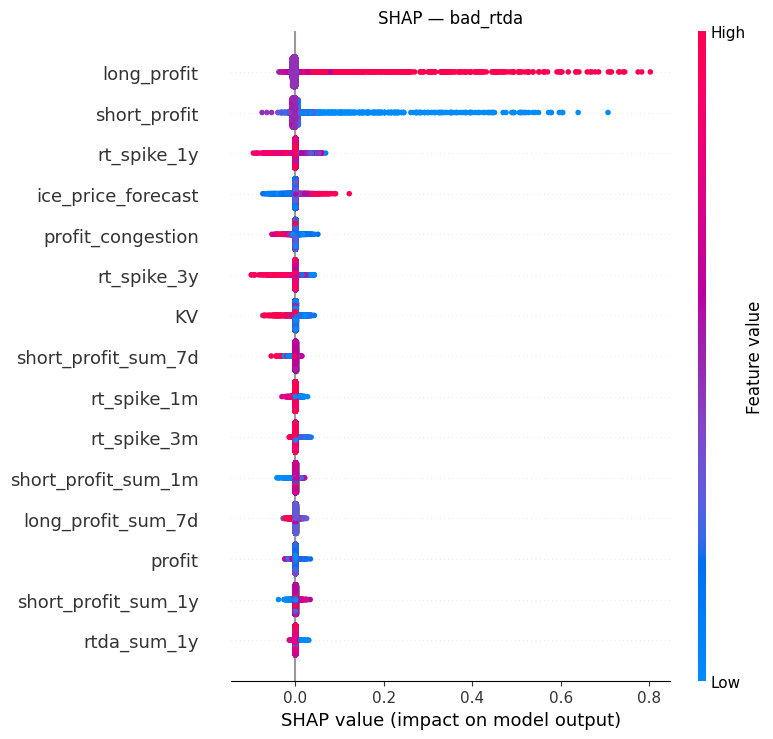

In [51]:
# === 3. SHAP summary plot (direction + magnitude) ===
import matplotlib.pyplot as plt
shap.summary_plot(rmt_spike['shap'], rmt_spike['X'], max_display=15, show=False)
plt.title('SHAP — bad_rtda'); plt.tight_layout(); plt.show()

In [52]:
# === 4. control tradeoff: cutting the worst tail of a driver ===
# For a candidate driver, drop the family-days in its 'bad' tail and measure
# short loss avoided vs long profit sacrificed. Set high_is_bad from the SHAP plot.
def cut_tradeoff(df, feat, q=0.10, high_is_bad=True):
    s = df[feat]
    thr = s.quantile(1 - q) if high_is_bad else s.quantile(q)
    cut = (s >= thr) if high_is_bad else (s <= thr)
    return pd.Series({
        'feature': feat, 'threshold': round(thr, 3), 'cut_frac': round(cut.mean(), 3),
        'short_loss_avoided': -df.loc[cut, 'short_profit'].sum(),   # >0 = loss removed
        'long_profit_lost':    df.loc[cut, 'long_profit'].sum(),    # >0 = profit forgone
        'net_benefit':       -df.loc[cut, 'short_profit'].sum() - df.loc[cut, 'long_profit'].sum(),
    })

# evaluate the top bad_rtda drivers on the holdout (set high_is_bad per SHAP direction)
top_drivers = rmt_spike['imp'].head(6).index.tolist()
tradeoff = pd.DataFrame([cut_tradeoff(holdout_df, f, q=0.10, high_is_bad=True)
                         for f in top_drivers if f in holdout_df.columns])
display(tradeoff.sort_values('net_benefit', ascending=False))

,feature,threshold,cut_frac,short_loss_avoided,long_profit_lost,net_benefit
2,rt_spike_1y,0.000,0.264,1.681995e+06,8.350504e+05,8.469443e+05
4,ice_price_forecast,58.283,0.101,5.220654e+06,3.471966e+07,-2.949900e+07
5,KV,345.000,0.110,-7.328965e+06,2.224744e+07,-2.957640e+07
1,short_profit,0.000,0.964,-2.652770e+08,-2.087124e+08,-5.656468e+07
3,profit_congestion,36728.262,0.100,-2.048210e+07,8.716376e+07,-1.076459e+08
0,long_profit,0.000,0.957,2.762743e+08,3.978407e+08,-1.215664e+08


In [53]:
# === where does the BAD-RTDA forest split? ===
import numpy as np, pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text

bad_model = rmt_spike['model']
top_feats = rmt_spike['imp'].head(8).index.tolist()

# ---- A. exact split thresholds from the trained forest (gain-weighted) ----
tdf    = bad_model.booster_.trees_to_dataframe()
splits = tdf[tdf['split_feature'].notna()].copy()
splits['thr_num'] = pd.to_numeric(splits['threshold'], errors='coerce')  # NaN = categorical split

print("Split thresholds per top driver (gain-weighted, from the actual forest):\n")
rows = []
for f in top_feats:
    s = splits[splits['split_feature'] == f]
    if s.empty:
        rows.append({'feature': f, 'note': 'not used as a split'}); continue
    sn = s.dropna(subset=['thr_num'])
    if sn.empty:                                   # categorical (e.g. KV_group)
        rows.append({'feature': f, 'n_splits': len(s), 'note': 'categorical split'}); continue
    w = sn['split_gain']
    gain_wtd_thr = np.average(sn['thr_num'], weights=w)        # typical split point
    band = sn.groupby(pd.cut(sn['thr_num'], 10))['split_gain'].sum().idxmax()  # highest-gain band
    rows.append({'feature': f, 'n_splits': len(sn),
                 'total_gain': round(w.sum(), 1),
                 'median_thr': round(sn['thr_num'].median(), 4),
                 'gain_wtd_thr': round(gain_wtd_thr, 4),
                 'top_gain_band': str(band)})
display(pd.DataFrame(rows))

# top single split points overall (which feature@threshold buys the most gain)
print("\nTop 15 individual splits by gain:")
display(splits.dropna(subset=['thr_num'])
              .sort_values('split_gain', ascending=False)
              [['split_feature', 'thr_num', 'split_gain', 'count']].head(15).round(4))

# ---- B. shallow surrogate tree -> readable if/then rules for the forest's risk ----
Xm = holdout_df[features + CATS].copy()
for c in CATS: Xm[c] = Xm[c].astype('category')
# classifier -> P(bad_rtda); regressor -> predicted bad_rtda level (both usable as a risk score)
risk = bad_model.predict_proba(Xm)[:, 1] if hasattr(bad_model, 'predict_proba') else bad_model.predict(Xm)
hot  = (risk > np.quantile(risk, 0.90)).astype(int)      # explain the top-decile-risk region

Xt = holdout_df[features + CATS].copy()
for c in CATS: Xt[c] = Xt[c].astype('category').cat.codes
surr = DecisionTreeClassifier(max_depth=3, min_samples_leaf=500, random_state=0).fit(Xt, hot)
print(f"\nSurrogate tree (depth 3) — explains the forest's top-decile risk | "
      f"fidelity acc={surr.score(Xt, hot):.3f}\n")
print(export_text(surr, feature_names=list(Xt.columns), max_depth=3))

Split thresholds per top driver (gain-weighted, from the actual forest):



,feature,n_splits,total_gain,median_thr,gain_wtd_thr,top_gain_band
0,long_profit,1886,9523.9,28339.2320,97448.4762,"(56310.559, 117904.355]"
1,short_profit,1772,4412.7,-28397.9359,-81723.3817,"(-84374.358, -37724.158]"
2,rt_spike_1y,342,1645.8,-1266.0696,-985.4512,"(-885.096, -237.927]"
3,profit_congestion,494,453.2,5707.2003,10039.9259,"(2691.276, 10106.314]"
4,ice_price_forecast,533,802.6,44.5117,50.0959,"(23.338, 44.609]"
5,KV,175,464.8,195.5000,213.2185,"(191.15, 224.2]"
6,rt_spike_3y,365,1003.2,-1226.3345,-939.3772,"(-866.887, -211.84]"
7,rt_spike_1m,327,283.0,-955.2727,-994.8133,"(-763.418, -186.865]"



Top 15 individual splits by gain:


,split_feature,thr_num,split_gain,count
0,long_profit,91051.6055,497.375,603721
61,long_profit,91051.6055,467.980,603721
122,long_profit,91051.6055,440.322,603721
244,long_profit,91051.6055,398.077,603721
183,short_profit,-42319.3302,384.829,603721
305,long_profit,91051.6055,374.551,603721
366,long_profit,91051.6055,352.415,603721
427,long_profit,91051.6055,331.587,603721
488,long_profit,59942.0680,312.415,603721
549,long_profit,91051.6055,294.082,603721



Surrogate tree (depth 3) — explains the forest's top-decile risk | fidelity acc=0.933

|--- rtda_sum_1y <= -38034.57
|   |--- long_profit_sum_1m <= 48606.27
|   |   |--- rtda_min_3m <= -14547.19
|   |   |   |--- class: 0
|   |   |--- rtda_min_3m >  -14547.19
|   |   |   |--- class: 1
|   |--- long_profit_sum_1m >  48606.27
|   |   |--- long_profit <= 5652.45
|   |   |   |--- class: 0
|   |   |--- long_profit >  5652.45
|   |   |   |--- class: 1
|--- rtda_sum_1y >  -38034.57
|   |--- short_profit <= -39.82
|   |   |--- profit_congestion <= 12340.68
|   |   |   |--- class: 1
|   |   |--- profit_congestion >  12340.68
|   |   |   |--- class: 1
|   |--- short_profit >  -39.82
|   |   |--- FlowRatio <= 0.85
|   |   |   |--- class: 0
|   |   |--- FlowRatio >  0.85
|   |   |   |--- class: 0

